In [12]:
#Normalization
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Example dataset
data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})

# Apply Min-Max Normalization
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data)

# Convert back to DataFrame
normalized_df = pd.DataFrame(normalized_data, columns=data.columns)

print("Normalized Data (MinMaxScaler):")
print(normalized_df)

Normalized Data (MinMaxScaler):
      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


In [6]:
#z-score normalization
import pandas as pd

from sklearn.preprocessing import StandardScaler
# Example dataset
data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})


# Apply Standardization
scaler = StandardScaler()
standardized_data = scaler.fit_transform(data)#fit and transform the data

# Convert back to DataFrame
standardized_df = pd.DataFrame(standardized_data, columns=data.columns)

print("\nStandardized Data (Z-score):")
print(standardized_df)


Standardized Data (Z-score):
          A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


In [7]:
#Encoding Categorical Variables
df = pd.DataFrame({'Color': ['Red', 'Blue', 'Green', 'Red', 'Blue']})

# One-hot encoding
one_hot = pd.get_dummies(df, columns=['Color'])

print("\nOne-Hot Encoding:")
print(one_hot)


One-Hot Encoding:
   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


In [1]:
# Tips dataset transformations
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns

tips = sns.load_dataset("tips")

numeric_cols = tips.select_dtypes(include=['float64','int64']).columns

# Normalization  
scaler_minmax = MinMaxScaler()
tips_normalized = tips.copy()
tips_normalized[numeric_cols] = scaler_minmax.fit_transform(tips[numeric_cols])
print(tips_normalized.head())

# Standardization
scaler_standard = StandardScaler()
tips_standardized = tips.copy()
tips_standardized[numeric_cols] = scaler_standard.fit_transform(tips[numeric_cols])
print(tips_standardized.head())

# One-Hot Encoding
tips_onehot = pd.get_dummies(tips, columns=['sex','smoker','day','time'])
print(tips_onehot.head())


   total_bill       tip     sex smoker  day    time  size
0    0.291579  0.001111  Female     No  Sun  Dinner   0.2
1    0.152283  0.073333    Male     No  Sun  Dinner   0.4
2    0.375786  0.277778    Male     No  Sun  Dinner   0.4
3    0.431713  0.256667    Male     No  Sun  Dinner   0.2
4    0.450775  0.290000  Female     No  Sun  Dinner   0.6
   total_bill       tip     sex smoker  day    time      size
0   -0.314711 -1.439947  Female     No  Sun  Dinner -0.600193
1   -1.063235 -0.969205    Male     No  Sun  Dinner  0.453383
2    0.137780  0.363356    Male     No  Sun  Dinner  0.453383
3    0.438315  0.225754    Male     No  Sun  Dinner -0.600193
4    0.540745  0.443020  Female     No  Sun  Dinner  1.506958
   total_bill   tip  size  sex_Male  sex_Female  smoker_Yes  smoker_No  \
0       16.99  1.01     2     False        True       False       True   
1       10.34  1.66     3      True       False       False       True   
2       21.01  3.50     3      True       False       Fals

[0.72627656 0.1730423 ]
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


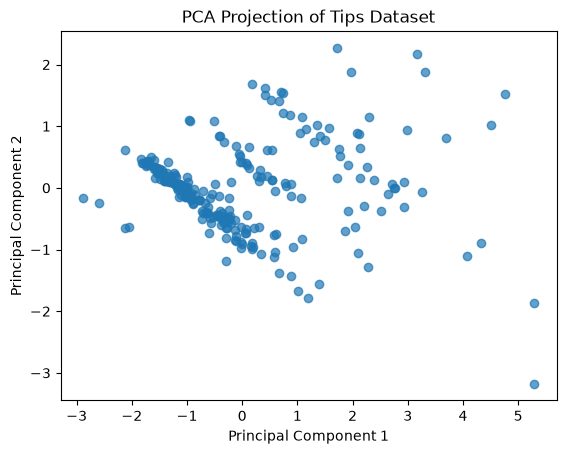

In [9]:
# PCA
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

tips = sns.load_dataset("tips")
numeric_cols = tips.select_dtypes(include=['float64','int64'])

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(data=pca_result, columns=['PC1','PC2'])
print(pca.explained_variance_ratio_)
print(pca_df.head())

plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Tips Dataset')
plt.show()

[0.9912126 0.0087874]
        LD1       LD2  target
0  8.143648 -0.303471       0
1  7.201062  0.794647       0
2  7.565869  0.268079       0
3  6.882372  0.677440       0
4  8.214873 -0.519686       0


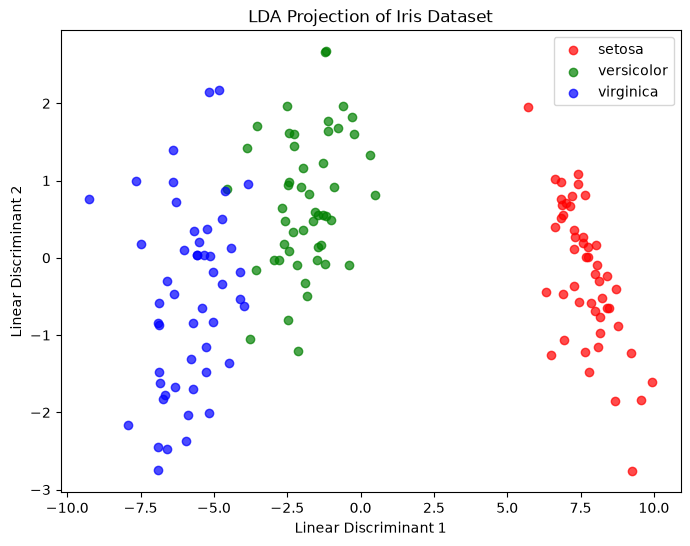

In [10]:
# LDA
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X, y)

lda_df = pd.DataFrame(X_lda, columns=['LD1', 'LD2'])
lda_df['target'] = y
print(lda.explained_variance_ratio_)
print(lda_df.head())

plt.figure(figsize=(8,6))
for label, color in zip([0,1,2], ['red','green','blue']):
    plt.scatter(
        lda_df.loc[lda_df['target']==label, 'LD1'],
        lda_df.loc[lda_df['target']==label, 'LD2'],
        label=iris.target_names[label],
        color=color,
        alpha=0.7
    )
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.title('LDA Projection of Iris Dataset')
plt.legend()
plt.show()

       TSNE1     TSNE2  target
0 -23.906771 -1.995415       0
1 -21.192930 -1.171225       0
2 -21.470705 -2.352272       0
3 -20.972347 -2.005782       0
4 -23.955744 -2.416308       0


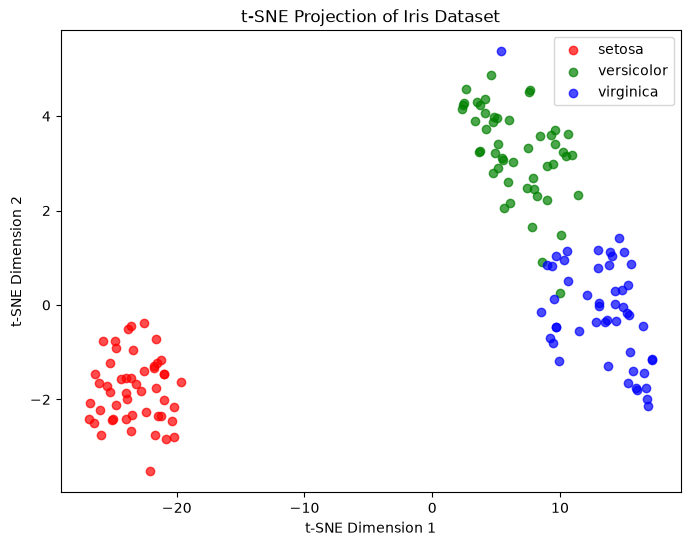

In [11]:
# t-SNE
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

iris = load_iris()
X = iris.data
y = iris.target

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X)

tsne_df = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
tsne_df['target'] = y
print(tsne_df.head())

plt.figure(figsize=(8, 6))
for label, color in zip([0, 1, 2], ['red', 'green', 'blue']):
    plt.scatter(
        tsne_df.loc[tsne_df['target'] == label, 'TSNE1'],
        tsne_df.loc[tsne_df['target'] == label, 'TSNE2'],
        label=iris.target_names[label],
        color=color,
        alpha=0.7
    )
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.title('t-SNE Projection of Iris Dataset')
plt.legend()
plt.show()
